# Agrupamiento Espectral sobre un dataset sintético
Vamos en este ejercicio a hacer un agrupamiento espectral descomponiéndolo en sus partes. Como sabéis, Scikit ofrece ya una implementación de este tipo de agrupamiento.  Sin embargo es importante fijar los contenidos pasos a paso sin esperar que una sola llamada a una función nos lo resuelva todo.
Vamos a trabajar con una base de datos sintética consistente en 3 círculos concéntricos a los que podemos introducir ruído para las figuras queden desdibujadas.

Este ejercicio está basado en la página del Dr. Juan Camilo Orduz

### Paso 1: Generación del dataset

Preparamos la configuración de colores

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid', {'axes.facecolor': '.9'})
sns.set_palette(palette='deep')
sns_c = sns.color_palette(palette='deep')
%matplotlib inline

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [2]:
# Set random state. 
rs = np.random.seed(25)

def generate_circle_sample_data(r, n, sigma):
    """Generate circle data with random Gaussian noise."""
    angles = np.random.uniform(low=0, high=2*np.pi, size=n)

    x_epsilon = np.random.normal(loc=0.0, scale=sigma, size=n)
    y_epsilon = np.random.normal(loc=0.0, scale=sigma, size=n)

    x = r*np.cos(angles) + x_epsilon
    y = r*np.sin(angles) + y_epsilon
    return x, y


def generate_concentric_circles_data(param_list):
    """Generates many circle data with random Gaussian noise."""
    coordinates = [ 
        generate_circle_sample_data(param[0], param[1], param[2])
     for param in param_list
    ]
    return coordinates

***Ejercicio 1:** Prueba a generar diferentes datasets modificando el parámetro sigma. Para ello modifica la lista 'sigmas' de la caja siguiente. Este parámetro es la desviacion típica de la gaussiana que genera el ruido. 
Escribe cuál es el efecto de aumentar el valor de sigma y en qué valor se pierde la estructura anular (nota: prueba valores desde 0.05 hasta 0.9).

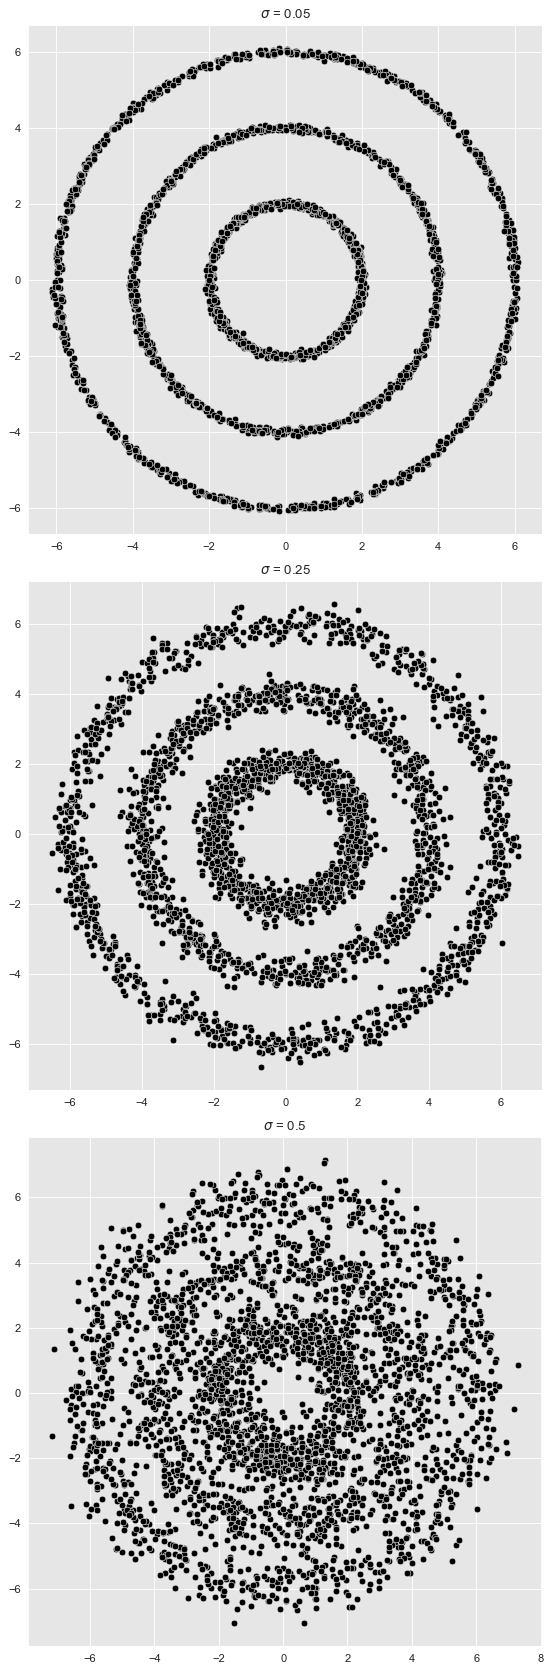

In [51]:
# Set global plot parameters. 
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['figure.dpi'] = 80

# Number of points per circle. 
n = 1000
# Radius. 
r_list =[2, 4, 6]
# Standar deviation (Gaussian noise). 
sigmas = [0.05,0.25,0.5]

param_lists = [[(r, n, sigma) for r in r_list] for sigma in sigmas] 
# We store the data on this list.
coordinates_list = []

fig, axes = plt.subplots(len(sigmas), 1, figsize=(7, 21))

for i, param_list in enumerate(param_lists):

    coordinates = generate_concentric_circles_data(param_list)

    coordinates_list.append(coordinates)
    
    ax = axes[i]
    
    for j in range(0, len(coordinates)):
    
        x, y = coordinates[j]
        sns.scatterplot(x=x, y=y, color='black', ax=ax)
        ax.set(title=f'$\sigma$ = {param_list[0][2]}')

plt.tight_layout()
plt.show() 

### Paso 2: Determinación del número de clusters k
Como sabemos, si tenemos un dataset del que no conocemos nada, un método para estimar el posible número de clusters es usar  K-Means y construir la gráfica 'elbow' como se vió.
Vamos a importar k-means y los incluiremos en un bucle para calcular las iniercias en función de k

             x         y
0    -0.654498 -1.945218
1    -1.199771  1.446076
2     1.670268 -1.188150
3    -1.842241 -0.758222
4     1.677079  1.115899
...        ...       ...
2995 -5.487816  2.720136
2996 -1.000133  5.944258
2997 -5.441060 -2.728541
2998  5.400418 -2.667249
2999 -4.923744  3.499620

[3000 rows x 2 columns]


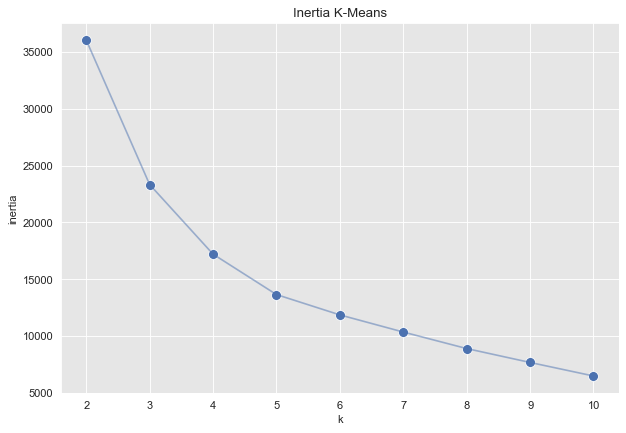

In [36]:
#Damos formato de Frame al primer conjunto de datos generados anteriormente
from itertools import chain

coordinates = coordinates_list[0]

def data_frame_from_coordinates(coordinates): 
    """From coordinates to data frame."""
    xs = chain(*[c[0] for c in coordinates])
    ys = chain(*[c[1] for c in coordinates])

    return pd.DataFrame(data={'x': xs, 'y': ys})

data_df = data_frame_from_coordinates(coordinates)

#Procedemos a ejecutar Kmeans
from sklearn.cluster import KMeans

inertias = []


print(data_df)

#Prepara una lista de valores de K desde 2 hasta 10, llámala k_candidates
k_candidates = list(range(2, 11))

#En cada iteración prepara un modelo de Kmeans con el parámetro random_state=42 para 
#revisarlo yo fácilmente y con un número de clusters de la lista que has preparado
for k in k_candidates:
    #prepara el modelo
    k_means = KMeans(n_clusters=k, random_state=42)
    #aplica el modelo a la base de datos
    k_means.fit(data_df)
    #añade a la lista de inercias la nueva inercia de este K-Means realizado en la iteracion
    inertias.append(k_means.inertia_)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(x=k_candidates, y = inertias, s=80, ax=ax)
#sns.scatterplot(x=[k_candidates[2]], y = [inertias[2]], color=sns_c[3], s=150, ax=ax)
sns.lineplot(x=k_candidates, y = inertias, alpha=0.5, ax=ax)
ax.set(title='Inertia K-Means', ylabel='inertia', xlabel='k');
plt.show() 

**Cuestión 1** ¿Mirando la curva que te ha salido, qué candidatos podrían ser buenos para establecer el número de clusters K?



Vamos a hacer un agrupamiento usando Kmeans con el número elegido de clusters sobre nuestro dataset para ver cómo se comporta

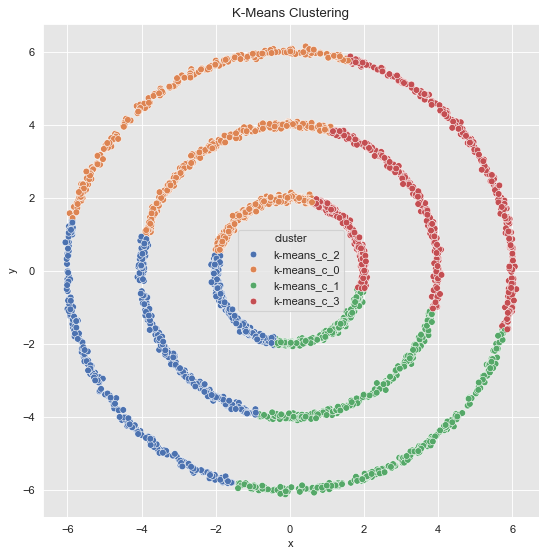

In [37]:
#prepara el modelo con el parámetro random_state=25
k_means = KMeans(n_clusters=4, random_state=42)
#ajusta el moodelo con el dataset
k_means.fit(data_df)
#Usa ahora el método predict para etiquetar los puntos
cluster = k_means.predict(data_df)

cluster = ['k-means_c_' + str(c) for c in cluster]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df.assign(cluster = cluster), hue='cluster', ax=ax)
ax.set(title='K-Means Clustering');
plt.show() 

**Cuestión2**: Valora el agrupamiento que realiza K-Means. ¿Por qué tiene ese comportamiento? (Escribe tu respuesta en esta caja)



### Paso 3: Construcción del grafo
Vamos a utilizar K vecinos más próximos. Podemos estudiar con otro tipo de grafos los resultados (grafos epsilon o  conectados con distancia decreciente gaussiana)

Para ello vamos a usar sklearn.neighbors.kneighbors_graph que nos devuelve la matriz de dimensión nXn con pesos para los k vecinos más próximos de cada vértice y 0 en el resto. Es pues una matriz de pesos dispersa.

**Importante**
La matriz de pesos dispersa que devuelve sklearn.neighbors.kneighbors_graph no es simétrica. Y necesitamos que la matriz de pesos W de la que se calcula la matriz laplaciana **Sí sea simétrica** para que también lo sea esta última.  El truco es sumar a la matriz dispersa su traspuesta y dividir los pesos por 2.

In [38]:
from sklearn.neighbors import kneighbors_graph
from scipy import sparse
#numero de vecinos
nn=8

connectivity = kneighbors_graph(X=data_df, n_neighbors=nn, mode='connectivity')
print(connectivity)
# Adjacency Matrix W.   Suma connectivity a su traspuesta y divide entre 2
adjacency_matrix_s = (connectivity + connectivity.T) / 2
print("-------")
print()
print(adjacency_matrix_s)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24000 stored elements and shape (3000, 3000)>
  Coords	Values
  (0, 577)	1.0
  (0, 492)	1.0
  (0, 272)	1.0
  (0, 579)	1.0
  (0, 310)	1.0
  (0, 737)	1.0
  (0, 364)	1.0
  (0, 43)	1.0
  (1, 415)	1.0
  (1, 623)	1.0
  (1, 27)	1.0
  (1, 209)	1.0
  (1, 448)	1.0
  (1, 80)	1.0
  (1, 219)	1.0
  (1, 751)	1.0
  (2, 82)	1.0
  (2, 951)	1.0
  (2, 952)	1.0
  (2, 966)	1.0
  (2, 36)	1.0
  (2, 444)	1.0
  (2, 581)	1.0
  (2, 170)	1.0
  (3, 872)	1.0
  :	:
  (2996, 2942)	1.0
  (2997, 2695)	1.0
  (2997, 2761)	1.0
  (2997, 2484)	1.0
  (2997, 2223)	1.0
  (2997, 2295)	1.0
  (2997, 2568)	1.0
  (2997, 2446)	1.0
  (2997, 2374)	1.0
  (2998, 2903)	1.0
  (2998, 2500)	1.0
  (2998, 2174)	1.0
  (2998, 2330)	1.0
  (2998, 2863)	1.0
  (2998, 2734)	1.0
  (2998, 2009)	1.0
  (2998, 2012)	1.0
  (2999, 2860)	1.0
  (2999, 2034)	1.0
  (2999, 2045)	1.0
  (2999, 2008)	1.0
  (2999, 2084)	1.0
  (2999, 2702)	1.0
  (2999, 2320)	1.0
  (2999, 2016)	1.0
-------

<Compressed Spar

Calculamos ahora la matriz laplaciana. Usamos el método sparse.csgraph.laplacian . 
**Actividad2:** Consulta sus parámetros en el manual de librerias. ¿Qué significa el parámetro 'normed'? Responde aquí



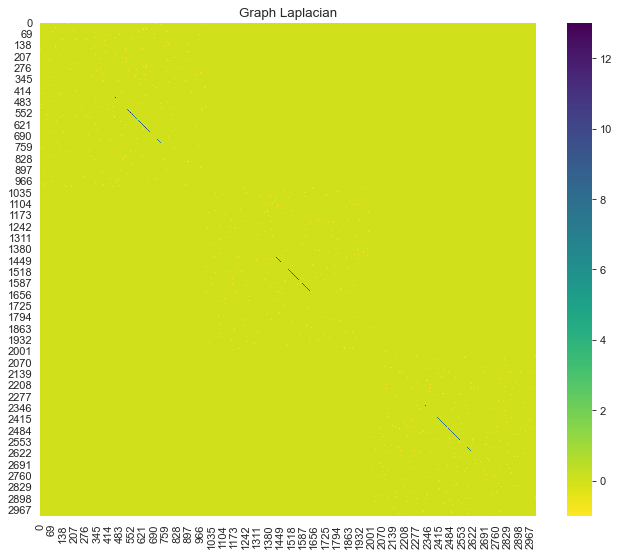

In [15]:
# Graph Laplacian.
graph_laplacian_s = sparse.csgraph.laplacian(csgraph=adjacency_matrix_s, normed=False)

#convierte la matriz en un array usando el método toarray()
graph_laplacian = graph_laplacian_s.toarray()
    
# Plot the graph Laplacian as heat map.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(graph_laplacian, ax=ax, cmap='viridis_r')
ax.set(title='Graph Laplacian');
plt.show() 

La matriz es dispersa. Notad las áreas verdes que indican valores próximos a cero.
Pero como la matriz tiene 9000000 de valores, no se aprecia bien el hecho de que no todos los valores son iguales.
Para verlo un poco mejor, reproducimos solo la submatrix 50x50 de la matriz laplaciana

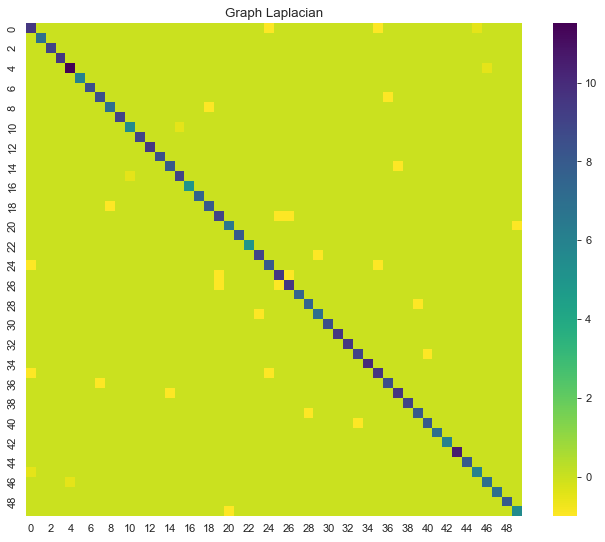

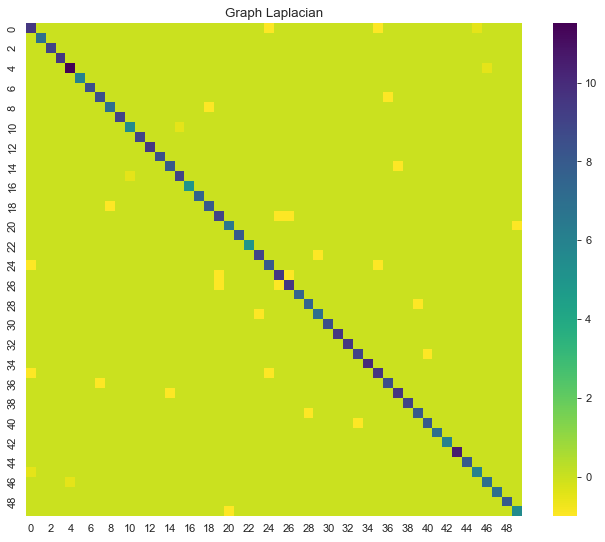

In [17]:
# Plot the 50x50 sub-Laplacian matrix as heat map.
M = graph_laplacian[0:50,0:50]

# Plot the graph Laplacian as heat map.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(M, ax=ax, cmap='viridis_r')
ax.set(title='Graph Laplacian');
plt.show() 

###  Paso 4: Obtención de los autovalores y autovectores de la matriz laplaciana

In [18]:
from scipy import linalg

eigenvals, eigenvcts = linalg.eig(graph_laplacian)

En general los autovalores son números complejos. Sin embargo sabemos que para matrices simétricas, los autovalores son  números reales. Compruébalo sacando la lista de valores complejos diferentes de los autovalores. Vemos que el único valor de la parte compleja es 0. 

In [19]:
np.unique(np.imag(eigenvals))

array([-3.97205465e-15, -3.55271368e-15,  0.00000000e+00,  3.55271368e-15,
        3.97205465e-15])

Vamos a quitar la parte compleja, que es 0, y vamos a dejar los autovalores con la parte real únicamente

In [20]:
eigenvals = np.real(eigenvals)
eigenvcts = np.real(eigenvcts)

Ordenamos de menor a mayor autovalor

In [29]:
from sklearn.preprocessing import normalize


eigenvals_sorted_indices = np.argsort(eigenvals)
eigenvals_sorted = eigenvals[eigenvals_sorted_indices]

#Comprobamos que los tres primeros autovalores son aproximadamente 0
zero_eigenvals_index = np.argwhere(abs(eigenvals_sorted) < 1e-5)
print(zero_eigenvals_index )
print("***************")


#También ordenamos los autovectores

indices = eigenvals_sorted_indices[: 3]


proj_df = pd.DataFrame(eigenvcts[:, indices])

print(proj_df)

proj_df.columns = ['v_' + str(c) for c in proj_df.columns]

#normalizamos la filas
proj_df = normalize(proj_df, axis=1)

print("-+-+-+-+")
print(proj_df)


[[0]
 [1]
 [2]]
***************
             0         1    2
0    -0.031623  0.000000  0.0
1    -0.031623  0.000000  0.0
2    -0.031623  0.000000  0.0
3    -0.031623  0.000000  0.0
4    -0.031623  0.000000  0.0
...        ...       ...  ...
2995  0.000000 -0.031623  0.0
2996  0.000000 -0.031623  0.0
2997  0.000000 -0.031623  0.0
2998  0.000000 -0.031623  0.0
2999  0.000000 -0.031623  0.0

[3000 rows x 3 columns]
-+-+-+-+
[[-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 ...
 [ 0. -1.  0.]
 [ 0. -1.  0.]
 [ 0. -1.  0.]]


Fíjate en los valores (normalizados) que hemos imprimido de los tres primeros autovectores, correspondientes al autovalor 0. Explica la forma que tienen y qué están indicando con los valores de sus coordenadas
**Respuesta:**




Vamos a visualizar ahora los autovalores en una gráfica:

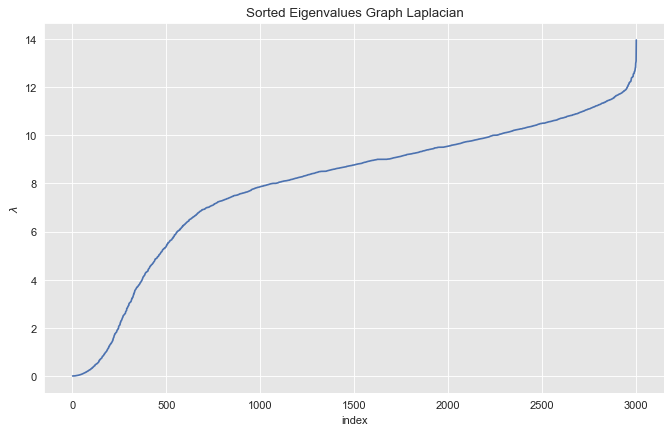

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=range(1, eigenvals_sorted_indices.size + 1), y=eigenvals_sorted, ax=ax)
ax.set(title='Sorted Eigenvalues Graph Laplacian', xlabel='index', ylabel=r'$\lambda$');
plt.show()

Hay tantos autovalores como dimensión de la matriz, es decir, como datos en el dataset.
Sin embargo los más interesantes para nosotros son los iniciales que forman un conjunto de valores nulos y el primer valor que se separa sustancialmente de 0 (llamado valor Fidler). Vamos a escalar la gráfica centrándonos en esa zona

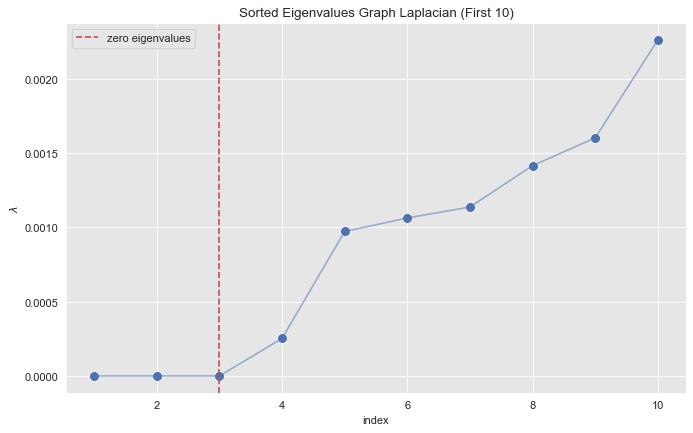

In [31]:
index_lim = 10

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], s=80, ax=ax)
sns.lineplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], alpha=0.5, ax=ax)
ax.axvline(x=3, color=sns_c[3], label='zero eigenvalues', linestyle='--')
ax.legend()
ax.set(title=f'Sorted Eigenvalues Graph Laplacian (First {index_lim})', xlabel='index', ylabel=r'$\lambda$');
plt.show()

Podemos ver que la descomposición espectral nos está indicando con el número de autovalores 0 que existen **Tres** componentes conectadas en este grafo (que coincidirán con los tres círculos concéntricos de la figura). En este ejemplo sintético las cosas están muy claras. Hay claramente tres componentes conexas que son los tres anillos concéntricos. Con datos reales, hay ruído y las cosas no son tan claras como aparecen aquí.

### Paso 5: Uso de KMeans para agrupar los autovectores
Como ya sabemos, debemos considerar ahora la matriz de los autovectores por columnas y agruparlas como si fueran datos por filas. Por el análisis espectral y por la curva de 'elbow' sabemos que k=3 es un valor prometedor (podeis pensar "pero si ya lo sé porque los datos son tres círculos concéntricos". Pero daros cuenta que en general NO SABEMOS A PRIORI la distribución de los datos, así que la especulación de que k=3 debe venir por estos métodos de análisis (espectral y 'elbow'). 
Preparamos así una matriz con los autovectores T de dimensión n X 3

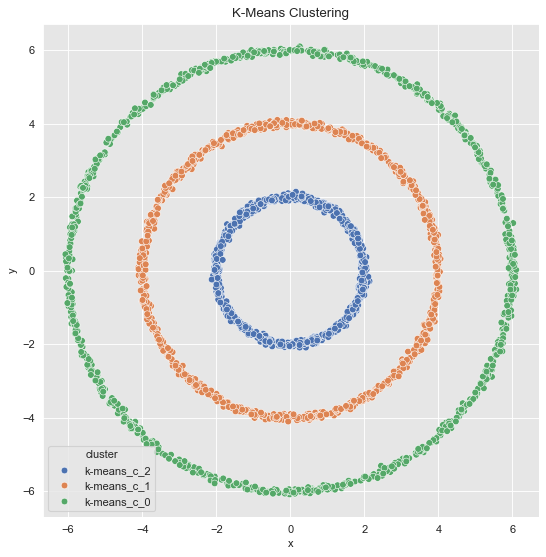

In [34]:
#Prepara KMeans con el modelo para 3 clusters , usa random_state=25
k_means = KMeans(n_clusters=3, random_state=25)
#Ajusta el modelo con nuestro dataset de componentes de autovectores
k_means.fit(proj_df)

#Predice las etiquetas de nuestros puntos
cluster_autoval = k_means.predict(proj_df)

cluster_autoval = ['k-means_c_' + str(c) for c in cluster_autoval]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df.assign(cluster = cluster_autoval), hue='cluster', ax=ax)
ax.set(title='K-Means Clustering');
plt.show()

**Cuestión 3:** Valora los resultados del agrupamient espectral para este dataset




**Actividad 3:**  **Realiza todos los pasos con los datasets generados para $$\sigma = 0.25$$ y $$\sigma = 0.5$$**

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24000 stored elements and shape (3000, 3000)>
  Coords	Values
  (0, 942)	1.0
  (0, 523)	1.0
  (0, 423)	1.0
  (0, 442)	1.0
  (0, 128)	1.0
  (0, 776)	1.0
  (0, 839)	1.0
  (0, 824)	1.0
  (1, 520)	1.0
  (1, 517)	1.0
  (1, 968)	1.0
  (1, 632)	1.0
  (1, 940)	1.0
  (1, 350)	1.0
  (1, 480)	1.0
  (1, 112)	1.0
  (2, 591)	1.0
  (2, 120)	1.0
  (2, 272)	1.0
  (2, 232)	1.0
  (2, 962)	1.0
  (2, 149)	1.0
  (2, 19)	1.0
  (2, 280)	1.0
  (3, 329)	1.0
  :	:
  (2996, 2606)	1.0
  (2997, 2392)	1.0
  (2997, 2110)	1.0
  (2997, 2971)	1.0
  (2997, 2806)	1.0
  (2997, 2145)	1.0
  (2997, 2316)	1.0
  (2997, 2919)	1.0
  (2997, 2501)	1.0
  (2998, 2601)	1.0
  (2998, 2510)	1.0
  (2998, 2660)	1.0
  (2998, 2071)	1.0
  (2998, 2944)	1.0
  (2998, 2549)	1.0
  (2998, 2031)	1.0
  (2998, 2704)	1.0
  (2999, 2013)	1.0
  (2999, 2129)	1.0
  (2999, 2590)	1.0
  (2999, 2034)	1.0
  (2999, 2027)	1.0
  (2999, 2271)	1.0
  (2999, 2496)	1.0
  (2999, 2625)	1.0


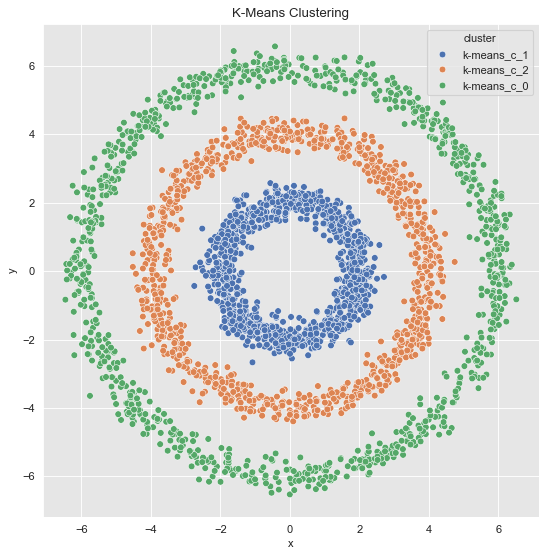

In [41]:
#Damos formato de Frame al primer conjunto de datos generados anteriormente
from itertools import chain

coordinates = coordinates_list[1]

data_df = data_frame_from_coordinates(coordinates)

connectivity = kneighbors_graph(X=data_df, n_neighbors=nn, mode='connectivity')
print(connectivity)
# Adjacency Matrix W.   Suma connectivity a su traspuesta y divide entre 2
adjacency_matrix_s = (connectivity + connectivity.T) / 2

# Graph Laplacian.
graph_laplacian_s = sparse.csgraph.laplacian(csgraph=adjacency_matrix_s, normed=False)

#convierte la matriz en un array usando el método toarray()
graph_laplacian = graph_laplacian_s.toarray()

eigenvals, eigenvcts = linalg.eig(graph_laplacian)

eigenvals = np.real(eigenvals)
eigenvcts = np.real(eigenvcts)

eigenvals_sorted_indices = np.argsort(eigenvals)
eigenvals_sorted = eigenvals[eigenvals_sorted_indices]

#Comprobamos que los tres primeros autovalores son aproximadamente 0
zero_eigenvals_index = np.argwhere(abs(eigenvals_sorted) < 1e-5)

#También ordenamos los autovectores

indices = eigenvals_sorted_indices[: 3]

proj_df = pd.DataFrame(eigenvcts[:, indices])


proj_df.columns = ['v_' + str(c) for c in proj_df.columns]

#normalizamos la filas
proj_df = normalize(proj_df, axis=1)

#Prepara KMeans con el modelo para 3 clusters , usa random_state=25
k_means = KMeans(n_clusters=3, random_state=25)
#Ajusta el modelo con nuestro dataset de componentes de autovectores
k_means.fit(proj_df)

#Predice las etiquetas de nuestros puntos
cluster_autoval = k_means.predict(proj_df)

cluster_autoval = ['k-means_c_' + str(c) for c in cluster_autoval]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df.assign(cluster = cluster_autoval), hue='cluster', ax=ax)
ax.set(title='K-Means Clustering');
plt.show()


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24000 stored elements and shape (3000, 3000)>
  Coords	Values
  (0, 1084)	1.0
  (0, 1145)	1.0
  (0, 1167)	1.0
  (0, 1319)	1.0
  (0, 1946)	1.0
  (0, 1908)	1.0
  (0, 1450)	1.0
  (0, 571)	1.0
  (1, 736)	1.0
  (1, 50)	1.0
  (1, 724)	1.0
  (1, 214)	1.0
  (1, 880)	1.0
  (1, 496)	1.0
  (1, 609)	1.0
  (1, 947)	1.0
  (2, 276)	1.0
  (2, 316)	1.0
  (2, 617)	1.0
  (2, 629)	1.0
  (2, 84)	1.0
  (2, 94)	1.0
  (2, 968)	1.0
  (2, 957)	1.0
  (3, 742)	1.0
  :	:
  (2996, 2659)	1.0
  (2997, 2927)	1.0
  (2997, 2175)	1.0
  (2997, 2954)	1.0
  (2997, 2636)	1.0
  (2997, 2811)	1.0
  (2997, 2717)	1.0
  (2997, 2675)	1.0
  (2997, 2409)	1.0
  (2998, 2814)	1.0
  (2998, 2641)	1.0
  (2998, 2897)	1.0
  (2998, 2499)	1.0
  (2998, 2990)	1.0
  (2998, 2377)	1.0
  (2998, 2118)	1.0
  (2998, 2646)	1.0
  (2999, 2221)	1.0
  (2999, 2784)	1.0
  (2999, 2609)	1.0
  (2999, 2698)	1.0
  (2999, 1808)	1.0
  (2999, 2617)	1.0
  (2999, 2766)	1.0
  (2999, 1928)	1.0


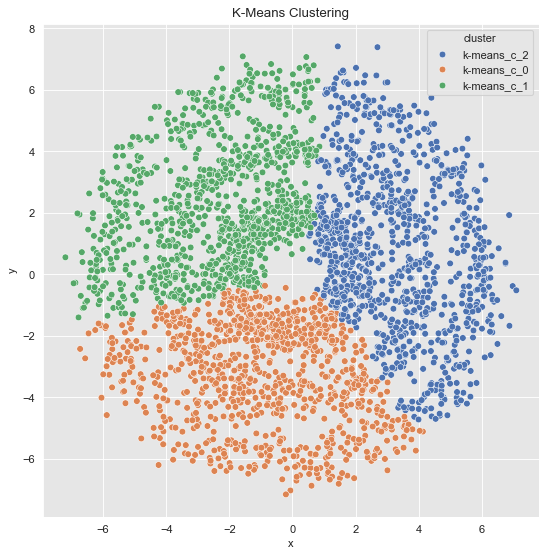

In [42]:
#Damos formato de Frame al primer conjunto de datos generados anteriormente
from itertools import chain

coordinates = coordinates_list[2]

data_df = data_frame_from_coordinates(coordinates)

connectivity = kneighbors_graph(X=data_df, n_neighbors=nn, mode='connectivity')
print(connectivity)
# Adjacency Matrix W.   Suma connectivity a su traspuesta y divide entre 2
adjacency_matrix_s = (connectivity + connectivity.T) / 2

# Graph Laplacian.
graph_laplacian_s = sparse.csgraph.laplacian(csgraph=adjacency_matrix_s, normed=False)

#convierte la matriz en un array usando el método toarray()
graph_laplacian = graph_laplacian_s.toarray()

eigenvals, eigenvcts = linalg.eig(graph_laplacian)

eigenvals = np.real(eigenvals)
eigenvcts = np.real(eigenvcts)

eigenvals_sorted_indices = np.argsort(eigenvals)
eigenvals_sorted = eigenvals[eigenvals_sorted_indices]

#Comprobamos que los tres primeros autovalores son aproximadamente 0
zero_eigenvals_index = np.argwhere(abs(eigenvals_sorted) < 1e-5)

#También ordenamos los autovectores

indices = eigenvals_sorted_indices[: 3]

proj_df = pd.DataFrame(eigenvcts[:, indices])


proj_df.columns = ['v_' + str(c) for c in proj_df.columns]

#normalizamos la filas
proj_df = normalize(proj_df, axis=1)

#Prepara KMeans con el modelo para 3 clusters , usa random_state=25
k_means = KMeans(n_clusters=3, random_state=25)
#Ajusta el modelo con nuestro dataset de componentes de autovectores
k_means.fit(proj_df)

#Predice las etiquetas de nuestros puntos
cluster_autoval = k_means.predict(proj_df)

cluster_autoval = ['k-means_c_' + str(c) for c in cluster_autoval]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df.assign(cluster = cluster_autoval), hue='cluster', ax=ax)
ax.set(title='K-Means Clustering');
plt.show()

**Actividad 4** Escribe aquí la valoración de los resultados obtenidos en los dos datasets que acabas de realizar en comparación con el primer dataset

## Agrupamiento Espectral con la librería Scikit
Aunque hemos hecho todos los pasos en este ejercicio para comprender cómo se produce al agrupamiento espectral, existe una instrucción en la librería Scikit que realiza todos los pasos anteriormente dados.

**Cuestión 4:** Consulta la librería y describe lo que significan las opciones que se usan en la caja de abajo



C:\Users\victo\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


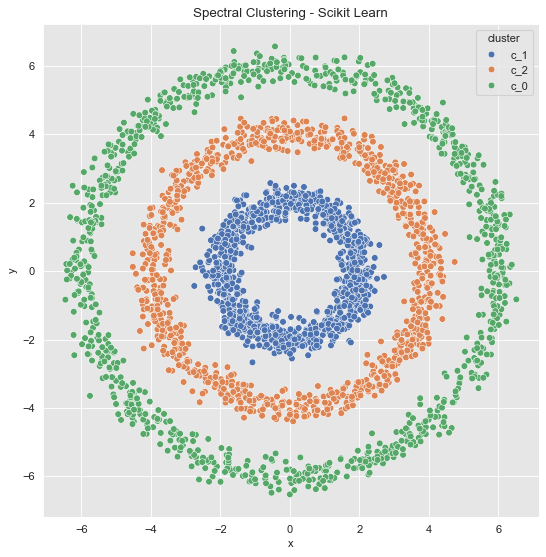

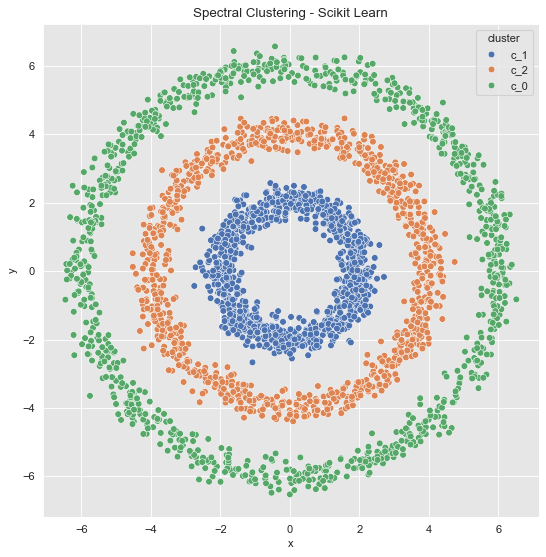

In [44]:
from sklearn.cluster import SpectralClustering

#damos formato de dataframe a uno de los conjuntos de datos (el del medio)
data_df = data_frame_from_coordinates(coordinates_list[1])


#Estudia diferentes valores de n_neighbors para ver las diferencias de resultados
spec_cl = SpectralClustering(
    n_clusters=3, 
    random_state=25, 
    n_neighbors=8, 
    affinity='nearest_neighbors'
)

data_df['cluster'] = spec_cl.fit_predict(data_df[['x', 'y']])
data_df['cluster'] = ['c_' + str(c) for c in data_df['cluster']]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df, hue='cluster', ax=ax)
ax.set(title='Spectral Clustering - Scikit Learn');
plt.show()


**Cuestión 5:** ¿Qué hace el parámetro n_neighbors? ¿tiene importancia en los resultados el parámetro n_neighbors? 

**Actividad 4:** Aplica la instrucción de scikit sobre los dos restantes datasets. Escribe el código en cajas abajo de ésta.

**Cuestión 6:** Compara los resultados con los que has obtenido en la PARTE 1. Explica especialmente lo que ocurre en el dataset con $$\sigma = 0.5$$. Escribe tu valoración en una caja abajo.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


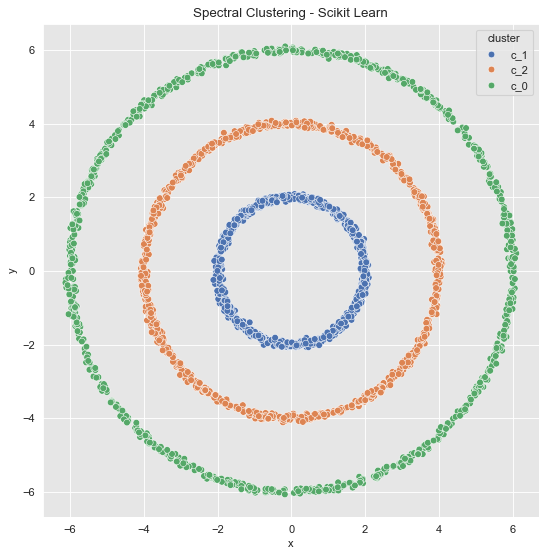

In [54]:
#damos formato de dataframe a uno de los conjuntos de datos (el del medio)
data_df = data_frame_from_coordinates(coordinates_list[0])


#Estudia diferentes valores de n_neighbors para ver las diferencias de resultados
spec_cl = SpectralClustering(
    n_clusters=3, 
    random_state=25, 
    n_neighbors=10, 
    affinity='nearest_neighbors'
)

data_df['cluster'] = spec_cl.fit_predict(data_df[['x', 'y']])
data_df['cluster'] = ['c_' + str(c) for c in data_df['cluster']]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df, hue='cluster', ax=ax)
ax.set(title='Spectral Clustering - Scikit Learn');
plt.show()

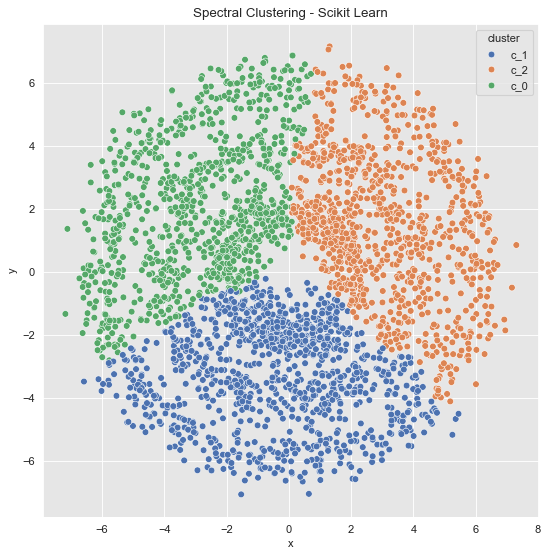

In [56]:
#damos formato de dataframe a uno de los conjuntos de datos (el del medio)
data_df = data_frame_from_coordinates(coordinates_list[2])


#Estudia diferentes valores de n_neighbors para ver las diferencias de resultados
spec_cl = SpectralClustering(
    n_clusters=3, 
    random_state=25, 
    n_neighbors=8, 
    affinity='nearest_neighbors'
)

data_df['cluster'] = spec_cl.fit_predict(data_df[['x', 'y']])
data_df['cluster'] = ['c_' + str(c) for c in data_df['cluster']]

fig, ax = plt.subplots()
sns.scatterplot(x='x', y='y', data=data_df, hue='cluster', ax=ax)
ax.set(title='Spectral Clustering - Scikit Learn');
plt.show()